# Vouzela Wildfire (Portugal) — TROPOMI Analysis, 2–3 July 2026

This notebook loads and analyzes Sentinel-5P TROPOMI data downloaded by
`scripts/download_tropomi.py` (or the `download-tropomi.yml` GitHub Action)
for the **Vouzela wildfire** event:

- **2 July 2026** — fire ignition near Tourelhe, Vouzela (Viseu district)
- **3 July 2026, 10:38 UTC** — Sentinel-3 captures the ~620 km smoke plume

> **Dependency note:** file loading uses the `h5netcdf` engine to read the
> TROPOMI `PRODUCT` group (the default `netCDF4` engine has a known bug that
> raises a spurious `KeyError` when opening many group datasets in a loop).
> Install it once with `pip install h5netcdf` if you don't already have it.

For each of the six TROPOMI species (**CO, NO₂, SO₂, HCHO, CH₄, O₃**) this
notebook:

1. Loads all orbit files available for 2 July and 3 July 2026
2. Applies the standard quality filter (`qa_value >= 0.75`)
3. Prints summary statistics (file count, mean, max, valid-pixel coverage)
4. Plots a map for each day
5. Plots a side-by-side 2 July vs 3 July comparison to show the plume forming
6. Builds a summary table across all six species



In [1]:
import os
import glob
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "white"

DATA_DIR = r'E:\TROPOMI_Portugal_Wildfires_2026\vouzela-wildfire-2026\data' # repo_root/data — adjust if running from elsewhere

print("Looking for data in:", os.path.abspath(DATA_DIR))
print("Exists:", os.path.isdir(DATA_DIR))


Looking for data in: E:\TROPOMI_Portugal_Wildfires_2026\vouzela-wildfire-2026\data
Exists: True


In [2]:
# TROPOMI L2 variable names (inside the 'PRODUCT' group) and a display-friendly
# label/colormap/unit for each species.
SPECIES = {
    "CO": {
        "var": "carbonmonoxide_total_column",
        "label": "CO total column",
        "unit": "mol/m²",
        "cmap": "inferno",
        "desc": "Carbon Monoxide — primary wildfire tracer",
    },
    "NO2": {
        "var": "nitrogendioxide_tropospheric_column",
        "label": "NO2 tropospheric column",
        "unit": "mol/m²",
        "cmap": "magma",
        "desc": "Nitrogen Dioxide — combustion indicator",
    },
    "SO2": {
        "var": "sulfurdioxide_total_vertical_column",
        "label": "SO2 total column",
        "unit": "mol/m²",
        "cmap": "plasma",
        "desc": "Sulphur Dioxide — fire/industrial marker",
    },
    "HCHO": {
        "var": "formaldehyde_tropospheric_vertical_column",
        "label": "HCHO tropospheric column",
        "unit": "mol/m²",
        "cmap": "viridis",
        "desc": "Formaldehyde — VOC biomass burning product",
    },
    "CH4": {
        "var": "methane_mixing_ratio_bias_corrected",
        "label": "CH4 mixing ratio (bias corrected)",
        "unit": "ppb",
        "cmap": "cividis",
        "desc": "Methane — greenhouse gas, elevated in fire plumes",
    },
    "O3": {
        "var": "ozone_total_vertical_column",
        "label": "O3 total column",
        "unit": "mol/m²",
        "cmap": "cubehelix",
        "desc": "Ozone — secondary pollutant, enhanced downwind",
    },
}

DATES = {
    "2026-07-02": "2 July — ignition day",
    "2026-07-03": "3 July — Sentinel-3 plume image day",
}

for sp, info in SPECIES.items():
    print(f"{sp:5s} -> {info['var']:45s} ({info['desc']})")


CO    -> carbonmonoxide_total_column                   (Carbon Monoxide — primary wildfire tracer)
NO2   -> nitrogendioxide_tropospheric_column           (Nitrogen Dioxide — combustion indicator)
SO2   -> sulfurdioxide_total_vertical_column           (Sulphur Dioxide — fire/industrial marker)
HCHO  -> formaldehyde_tropospheric_vertical_column     (Formaldehyde — VOC biomass burning product)
CH4   -> methane_mixing_ratio_bias_corrected           (Methane — greenhouse gas, elevated in fire plumes)
O3    -> ozone_total_vertical_column                   (Ozone — secondary pollutant, enhanced downwind)


In [3]:
def find_files(species, date_str):
    """Return .nc files for a species whose filename encodes the given date (YYYY-MM-DD)."""
    species_dir = os.path.join(DATA_DIR, species)
    if not os.path.isdir(species_dir):
        return []
    date_compact = date_str.replace("-", "")
    all_files = glob.glob(os.path.join(species_dir, "*.nc"))
    # TROPOMI filenames embed the sensing start date as e.g. ..._20260702T...
    return sorted(f for f in all_files if date_compact in os.path.basename(f))


def load_variable(fpath, varname, qa_threshold=0.75):
    """Open one TROPOMI file, apply the QA filter, and return (lon, lat, values) as flat arrays."""
    ds = None
    last_err = None
    # h5netcdf avoids a known netCDF4-engine bug when repeatedly opening
    # groups in a loop (spurious KeyError from netCDF4's internal cache).
    for engine in ("h5netcdf", "netcdf4"):
        try:
            ds = xr.open_dataset(fpath, group="PRODUCT", engine=engine)
            break
        except Exception as e:
            last_err = e
            continue
    if ds is None:
        print(f"    could not open {os.path.basename(fpath)}: {last_err}")
        return None, None, None

    if varname not in ds:
        print(f"    variable '{varname}' not found in {os.path.basename(fpath)}")
        ds.close()
        return None, None, None

    var = ds[varname]
    qa = ds["qa_value"] if "qa_value" in ds else None

    lon = ds["longitude"].values.ravel()
    lat = ds["latitude"].values.ravel()
    vals = var.values.ravel()

    if qa is not None:
        qa_vals = qa.values.ravel()
        mask = qa_vals >= qa_threshold
        lon, lat, vals = lon[mask], lat[mask], vals[mask]

    valid = ~np.isnan(vals)
    ds.close()
    return lon[valid], lat[valid], vals[valid]


def load_species_day(species, date_str):
    """Load & concatenate all orbit files for one species on one date. Returns lon, lat, vals arrays (possibly empty)."""
    files = find_files(species, date_str)
    info = SPECIES[species]
    print(f"  {species} / {date_str}: {len(files)} file(s) found")
    if not files:
        return np.array([]), np.array([]), np.array([])

    lons, lats, vals = [], [], []
    for f in files:
        lo, la, v = load_variable(f, info["var"])
        if lo is not None and len(lo):
            lons.append(lo); lats.append(la); vals.append(v)

    if not vals:
        return np.array([]), np.array([]), np.array([])

    return np.concatenate(lons), np.concatenate(lats), np.concatenate(vals)


In [4]:
results = {}  # results[species][date] = dict(lon, lat, vals, stats)

for species, info in SPECIES.items():
    print("=" * 70)
    print(f"{species} — {info['desc']}")
    print("=" * 70)
    results[species] = {}

    for date_str, date_label in DATES.items():
        lon, lat, vals = load_species_day(species, date_str)
        stats = {
            "n_points": int(vals.size),
            "mean": float(np.mean(vals)) if vals.size else None,
            "max": float(np.max(vals)) if vals.size else None,
            "min": float(np.min(vals)) if vals.size else None,
        }
        results[species][date_str] = {"lon": lon, "lat": lat, "vals": vals, "stats": stats}

        print(f"    {date_label}:")
        if stats["n_points"] == 0:
            print(f"      no valid (QA-filtered) data available yet")
        else:
            print(f"      valid pixels : {stats['n_points']:,}")
            print(f"      mean         : {stats['mean']:.4g} {info['unit']}")
            print(f"      max          : {stats['max']:.4g} {info['unit']}")
            print(f"      min          : {stats['min']:.4g} {info['unit']}")
    print()


CO — Carbon Monoxide — primary wildfire tracer
  CO / 2026-07-02: 7 file(s) found
    2 July — ignition day:
      valid pixels : 161,775
      mean         : 0.0252 mol/m²
      max          : 0.07286 mol/m²
      min          : 0.0009529 mol/m²
  CO / 2026-07-03: 9 file(s) found
    3 July — Sentinel-3 plume image day:
      valid pixels : 199,793
      mean         : 0.02543 mol/m²
      max          : 0.07695 mol/m²
      min          : 0.0002843 mol/m²

NO2 — Nitrogen Dioxide — combustion indicator
  NO2 / 2026-07-02: 7 file(s) found
    2 July — ignition day:
      valid pixels : 2,226,851
      mean         : 7.309e-06 mol/m²
      max          : 0.0002921 mol/m²
      min          : -4.745e-05 mol/m²
  NO2 / 2026-07-03: 8 file(s) found
    3 July — Sentinel-3 plume image day:
      valid pixels : 2,816,908
      mean         : 8.074e-06 mol/m²
      max          : 0.001001 mol/m²
      min          : -6.277e-05 mol/m²

SO2 — Sulphur Dioxide — fire/industrial marker
  SO2 / 2026

In [5]:
rows = []
for species, info in SPECIES.items():
    d2 = results[species]["2026-07-02"]["stats"]
    d3 = results[species]["2026-07-03"]["stats"]
    pct_change = None
    if d2["mean"] not in (None, 0) and d3["mean"] is not None:
        pct_change = 100 * (d3["mean"] - d2["mean"]) / abs(d2["mean"])

    rows.append({
        "species": species,
        "2_jul_mean": d2["mean"],
        "2_jul_max": d2["max"],
        "3_jul_mean": d3["mean"],
        "3_jul_max": d3["max"],
        "mean_pct_change": pct_change,
        "unit": info["unit"],
    })

summary_df = pd.DataFrame(rows).set_index("species")
print("Summary: 2 July (ignition) vs 3 July (plume image day)")
print(summary_df.to_string(float_format=lambda x: f"{x:,.4g}" if pd.notnull(x) else "n/a"))
summary_df


Summary: 2 July (ignition) vs 3 July (plume image day)
         2_jul_mean  2_jul_max  3_jul_mean  3_jul_max  mean_pct_change    unit
species                                                                       
CO           0.0252    0.07286     0.02543    0.07695           0.9063  mol/m²
NO2       7.309e-06  0.0002921   8.074e-06   0.001001            10.47  mol/m²
SO2       6.166e-06    0.01064   8.304e-06    0.03197            34.67  mol/m²
HCHO      7.301e-05   0.001123   7.653e-05    0.00131            4.818  mol/m²
CH4           1,901      2,016       1,901      2,061         0.001027     ppb
O3           0.1388     0.2008      0.1384     0.2008          -0.2797  mol/m²


,2_jul_mean,2_jul_max,3_jul_mean,3_jul_max,mean_pct_change,unit
species,,,,,,
CO,0.025198,0.072857,0.025427,0.076951,0.906324,mol/m²
NO2,0.000007,0.000292,0.000008,0.001001,10.468514,mol/m²
SO2,0.000006,0.010637,0.000008,0.031972,34.673550,mol/m²
HCHO,0.000073,0.001123,0.000077,0.001310,4.818189,mol/m²
CH4,1900.863647,2016.193359,1900.883179,2061.226074,0.001027,ppb
O3,0.138806,0.200816,0.138418,0.200816,-0.279664,mol/m²


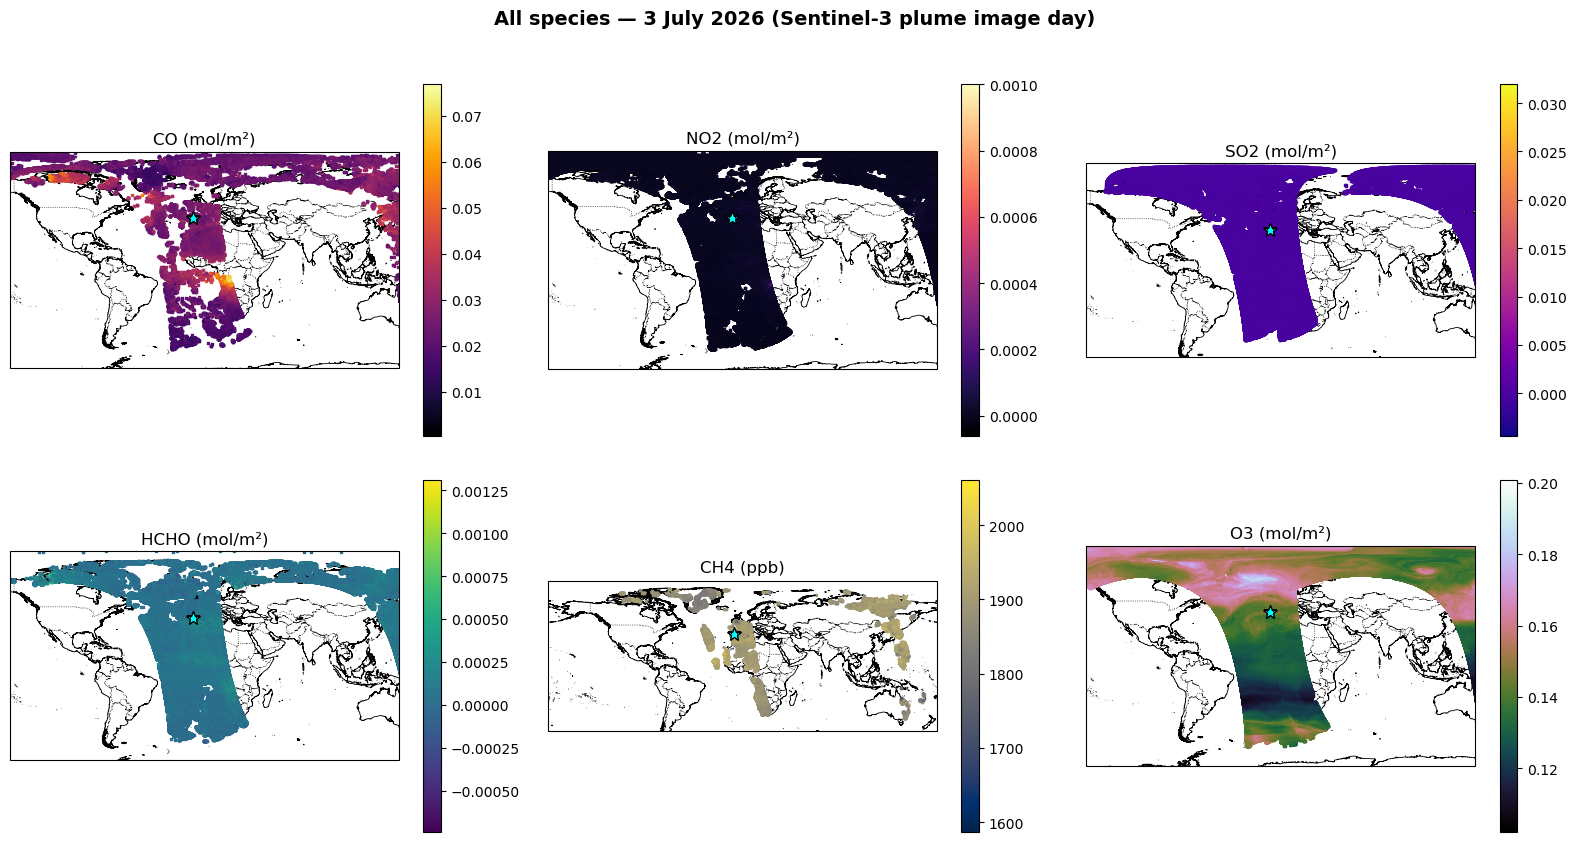

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

VOUZELA_LON, VOUZELA_LAT = -8.15, 40.75

fig, axes = plt.subplots(
    2, 3, figsize=(16, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
fig.suptitle("All species — 3 July 2026 (Sentinel-3 plume image day)", fontsize=14, fontweight="bold")

for ax, (species, info) in zip(axes.ravel(), SPECIES.items()):
    d = results[species]["2026-07-03"]

    ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.6)
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.5, linestyle=":")

    if d["stats"]["n_points"] == 0:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(species)
        continue

    sc = ax.scatter(
        d["lon"], d["lat"], c=d["vals"], cmap=info["cmap"], s=2, marker="s",
        transform=ccrs.PlateCarree(), zorder=2,
    )
    ax.plot(
        VOUZELA_LON, VOUZELA_LAT, marker="*", color="cyan", markersize=10,
        markeredgecolor="black", transform=ccrs.PlateCarree(), zorder=3,
    )

    lon_pad = (d["lon"].max() - d["lon"].min()) * 0.1 or 2.0
    lat_pad = (d["lat"].max() - d["lat"].min()) * 0.1 or 2.0
    ax.set_extent([
        d["lon"].min() - lon_pad, d["lon"].max() + lon_pad,
        d["lat"].min() - lat_pad, d["lat"].max() + lat_pad,
    ], crs=ccrs.PlateCarree())

    ax.set_title(f"{species} ({info['unit']})")
    plt.colorbar(sc, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()


Grid: 46 x 86 cells (~0.0818° lon x 0.0631° lat, ~7.0 km)
2026-07-02: 3117 / 3956 grid cells filled
2026-07-03: 3353 / 3956 grid cells filled
Saved regridded NetCDF -> E:\TROPOMI_Portugal_Wildfires_2026\vouzela-wildfire-2026\data\CO_portugal_7km_2026-07-02_03.nc


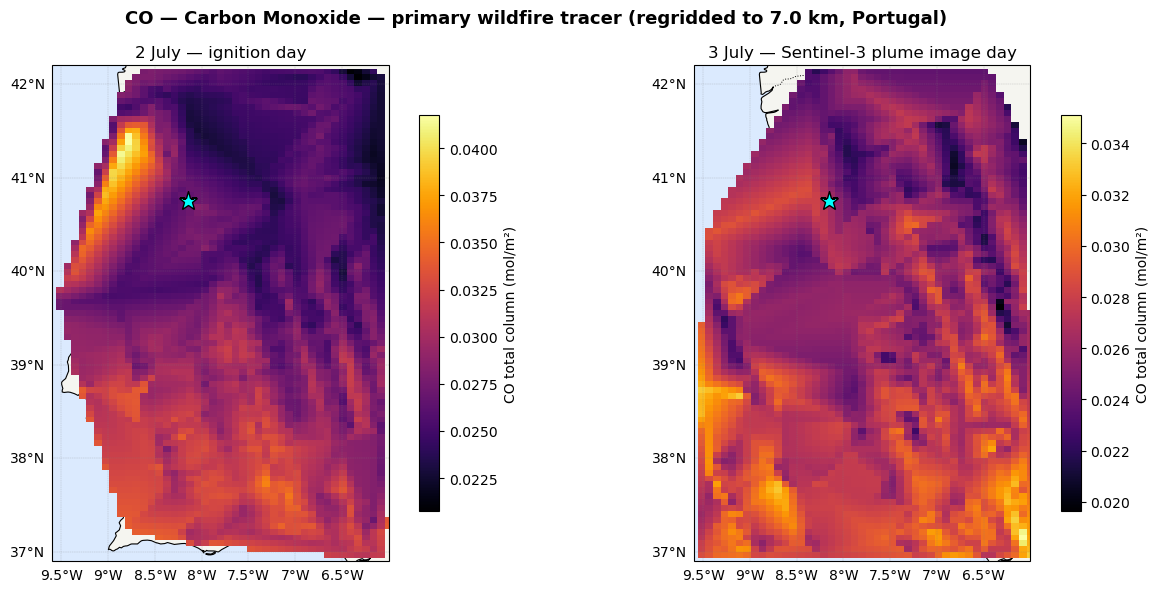

In [7]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ------------------------------------------------------------------
# 1. Portugal bounding box (adjust if you want to include more of Spain)
# ------------------------------------------------------------------
LON_MIN, LON_MAX = -9.6, -6.0
LAT_MIN, LAT_MAX = 36.9, 42.2

# ------------------------------------------------------------------
# 2. Build a uniform ~7 km grid
#    1 deg lat ≈ 111 km everywhere
#    1 deg lon ≈ 111 km * cos(lat) — use mid-latitude of the box
# ------------------------------------------------------------------
TARGET_RES_KM = 7.0
mid_lat = (LAT_MIN + LAT_MAX) / 2

dlat = TARGET_RES_KM / 111.0
dlon = TARGET_RES_KM / (111.0 * np.cos(np.radians(mid_lat)))

grid_lon = np.arange(LON_MIN, LON_MAX + dlon, dlon)
grid_lat = np.arange(LAT_MIN, LAT_MAX + dlat, dlat)
grid_lon2d, grid_lat2d = np.meshgrid(grid_lon, grid_lat)

print(f"Grid: {len(grid_lon)} x {len(grid_lat)} cells "
      f"(~{dlon:.4f}° lon x {dlat:.4f}° lat, ~{TARGET_RES_KM} km)")

# ------------------------------------------------------------------
# 3. Regrid one species/date's swath data onto that grid
# ------------------------------------------------------------------
def regrid_to_portugal(lon, lat, vals, method="linear"):
    """Interpolate scattered swath pixels onto the uniform Portugal grid."""
    if len(vals) == 0:
        return np.full(grid_lon2d.shape, np.nan)

    # Restrict input points to the bounding box first (faster + cleaner)
    mask = (
        (lon >= LON_MIN) & (lon <= LON_MAX) &
        (lat >= LAT_MIN) & (lat <= LAT_MAX)
    )
    lon_p, lat_p, vals_p = lon[mask], lat[mask], vals[mask]

    if len(vals_p) < 4:
        return np.full(grid_lon2d.shape, np.nan)

    gridded = griddata(
        points=(lon_p, lat_p),
        values=vals_p,
        xi=(grid_lon2d, grid_lat2d),
        method=method,
        fill_value=np.nan,
    )
    # Fill small interior gaps left by "linear" with a nearest-neighbor pass,
    # but keep it NaN far outside the swath (griddata's convex hull already
    # limits "linear" — a nearest pass would extrapolate everywhere, so we
    # only use it to patch NaNs that are inside the linear hull's ragged edge).
    return gridded


# ------------------------------------------------------------------
# 4. Regrid CO (swap species if you want a different one) for both dates
#    and save as a NetCDF file
# ------------------------------------------------------------------
SPECIES_TO_REGRID = "CO"   # change to "NO2", "SO2", etc. as needed
DATES_TO_REGRID = ["2026-07-02", "2026-07-03"]

regridded_slices = []
for date_str in DATES_TO_REGRID:
    d = results[SPECIES_TO_REGRID][date_str]
    grid_vals = regrid_to_portugal(d["lon"], d["lat"], d["vals"])
    regridded_slices.append(grid_vals)
    n_valid = np.sum(~np.isnan(grid_vals))
    print(f"{date_str}: {n_valid} / {grid_vals.size} grid cells filled")

regridded_stack = np.stack(regridded_slices, axis=0)  # (time, lat, lon)

ds_out = xr.Dataset(
    data_vars={
        SPECIES_TO_REGRID: (["time", "lat", "lon"], regridded_stack),
    },
    coords={
        "time": pd.to_datetime(DATES_TO_REGRID),
        "lat": grid_lat,
        "lon": grid_lon,
    },
    attrs={
        "description": f"{SPECIES_TO_REGRID} regridded to {TARGET_RES_KM} km over Portugal",
        "unit": SPECIES[SPECIES_TO_REGRID]["unit"],
        "source": "Sentinel-5P TROPOMI L2",
    },
)

out_path = os.path.join(DATA_DIR, f"{SPECIES_TO_REGRID}_portugal_7km_2026-07-02_03.nc")
ds_out.to_netcdf(out_path)
print(f"Saved regridded NetCDF -> {out_path}")

# ------------------------------------------------------------------
# 5. Plot the regridded grid, zoomed to Portugal
# ------------------------------------------------------------------
info = SPECIES[SPECIES_TO_REGRID]
fig, axes = plt.subplots(
    1, 2, figsize=(13, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
fig.suptitle(
    f"{SPECIES_TO_REGRID} — {info['desc']} (regridded to {TARGET_RES_KM} km, Portugal)",
    fontsize=13, fontweight="bold",
)

for ax, date_str, date_label in zip(
    axes, DATES_TO_REGRID, ["2 July — ignition day", "3 July — Sentinel-3 plume image day"]
):
    ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.7, linestyle=":")
    ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="#dbeafe", zorder=0)
    ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="#f5f5f0", zorder=0)

    field = ds_out[SPECIES_TO_REGRID].sel(time=date_str).values
    pc = ax.pcolormesh(
        grid_lon, grid_lat, field,
        cmap=info["cmap"], shading="auto",
        transform=ccrs.PlateCarree(), zorder=2,
    )
    ax.plot(
        -8.15, 40.75, marker="*", color="cyan", markersize=14,
        markeredgecolor="black", transform=ccrs.PlateCarree(), zorder=3,
    )
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.set_title(date_label)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    plt.colorbar(pc, ax=ax, label=f"{info['label']} ({info['unit']})", shrink=0.8)

plt.tight_layout()
plt.show()

## Optional: overlay NASA FIRMS active-fire hotspots

Download VIIRS/MODIS active-fire points for 2–3 July 2026 over Portugal from
https://firms.modaps.eosdis.nasa.gov/download/ (CSV format) and save as
`data/firms_hotspots.csv`. Re-run the cell below once that file exists to
overlay fire detections on top of the CO map for source attribution.


Loaded 946 FIRMS hotspot detections
  -> 877 detections on 3 July 2026 (confidence breakdown: {'n': 703, 'h': 134, 'l': 40})


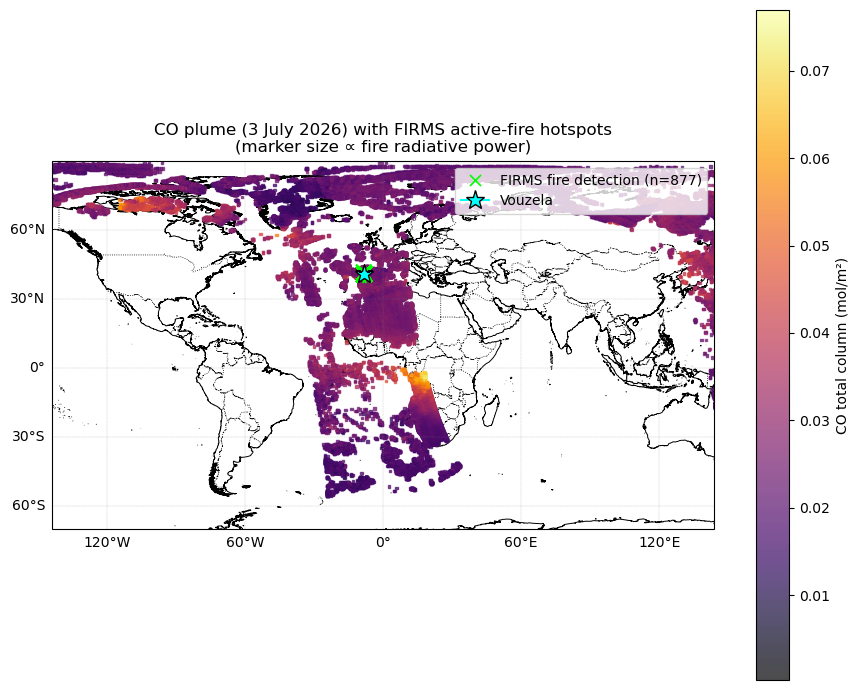

In [8]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# This is the real FIRMS filename as downloaded — point directly at it
# (or copy/rename it to firms_hotspots.csv in DATA_DIR to match the old path)
firms_path = r"E:\TROPOMI_Portugal_Wildfires_2026\vouzela-wildfire-2026\data\fire_nrt_SV-C2_774453.csv"

if os.path.exists(firms_path):
    firms = pd.read_csv(firms_path)
    print(f"Loaded {len(firms)} FIRMS hotspot detections")

    # Real FIRMS files span a date range, not just one day — filter to 3 July
    # to match the CO plume-image day. Also keep confidence 'n' (nominal) and
    # 'h' (high); FIRMS VIIRS uses letter codes, not the 0-100 scale MODIS uses.
    firms["acq_date"] = pd.to_datetime(firms["acq_date"])
    firms_3jul = firms[firms["acq_date"] == "2026-07-03"].copy()
    print(f"  -> {len(firms_3jul)} detections on 3 July 2026 "
          f"(confidence breakdown: {firms_3jul['confidence'].value_counts().to_dict()})")

    d = results["CO"]["2026-07-03"]
    fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={"projection": ccrs.PlateCarree()})
    ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.7)
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.6, linestyle=":")

    if d["stats"]["n_points"] > 0:
        sc = ax.scatter(
            d["lon"], d["lat"], c=d["vals"], cmap="inferno", s=3, marker="s", alpha=0.7,
            transform=ccrs.PlateCarree(), zorder=2,
        )
        plt.colorbar(sc, ax=ax, label="CO total column (mol/m²)")
        lon_pad = (d["lon"].max() - d["lon"].min()) * 0.1 or 2.0
        lat_pad = (d["lat"].max() - d["lat"].min()) * 0.1 or 2.0
        ax.set_extent([
            d["lon"].min() - lon_pad, d["lon"].max() + lon_pad,
            d["lat"].min() - lat_pad, d["lat"].max() + lat_pad,
        ], crs=ccrs.PlateCarree())

    # Size/color hotspots by Fire Radiative Power (frp) so intensity is visible
    sizes = np.clip(firms_3jul["frp"] * 3, 8, 120)
    ax.scatter(
        firms_3jul["longitude"], firms_3jul["latitude"],
        c="lime", s=sizes, marker="x", linewidths=1.2,
        label=f"FIRMS fire detection (n={len(firms_3jul)})",
        transform=ccrs.PlateCarree(), zorder=3,
    )

    ax.plot(
        -8.15, 40.75, marker="*", color="cyan", markersize=14, markeredgecolor="black",
        label="Vouzela", transform=ccrs.PlateCarree(), zorder=4,
    )
    ax.set_title("CO plume (3 July 2026) with FIRMS active-fire hotspots\n(marker size ∝ fire radiative power)")

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
else:
    print(f"No FIRMS file found at {firms_path} — skipping overlay.")
    print("Download one from https://firms.modaps.eosdis.nasa.gov/download/ to enable this cell.")

Loaded 877 FIRMS detections on 3 July 2026


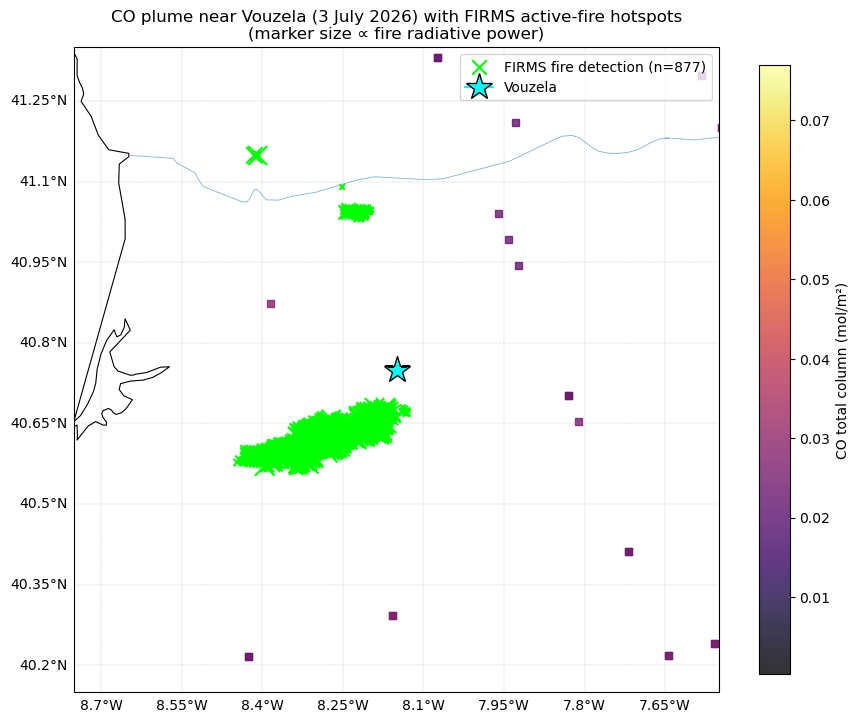

In [9]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

firms_path = os.path.join(DATA_DIR, "fire_nrt_SV-C2_774453.csv")

if os.path.exists(firms_path):
    firms = pd.read_csv(firms_path)
    firms["acq_date"] = pd.to_datetime(firms["acq_date"])
    firms_3jul = firms[firms["acq_date"] == "2026-07-03"].copy()
    print(f"Loaded {len(firms_3jul)} FIRMS detections on 3 July 2026")

    d = results["CO"]["2026-07-03"]

    # --- Tight zoom around Vouzela, not the full CO swath extent ---
    VOUZELA_LON, VOUZELA_LAT = -8.15, 40.75
    ZOOM_DEG = 0.6   # ~65 km box; shrink to e.g. 0.3 for an even tighter view

    fig, ax = plt.subplots(figsize=(9, 8), subplot_kw={"projection": ccrs.PlateCarree()})
    ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.6, linestyle=":")
    ax.add_feature(cfeature.RIVERS.with_scale("10m"), edgecolor="#7fb3d5", linewidth=0.6)

    if d["stats"]["n_points"] > 0:
        sc = ax.scatter(
            d["lon"], d["lat"], c=d["vals"], cmap="inferno", s=25, marker="s", alpha=0.8,
            transform=ccrs.PlateCarree(), zorder=2,
        )
        plt.colorbar(sc, ax=ax, label="CO total column (mol/m²)", shrink=0.8)

    sizes = np.clip(firms_3jul["frp"] * 4, 15, 200)
    ax.scatter(
        firms_3jul["longitude"], firms_3jul["latitude"],
        c="lime", s=sizes, marker="x", linewidths=1.5,
        label=f"FIRMS fire detection (n={len(firms_3jul)})",
        transform=ccrs.PlateCarree(), zorder=3,
    )

    ax.plot(
        VOUZELA_LON, VOUZELA_LAT, marker="*", color="cyan", markersize=20,
        markeredgecolor="black", label="Vouzela", transform=ccrs.PlateCarree(), zorder=4,
    )

    ax.set_extent([
        VOUZELA_LON - ZOOM_DEG, VOUZELA_LON + ZOOM_DEG,
        VOUZELA_LAT - ZOOM_DEG, VOUZELA_LAT + ZOOM_DEG,
    ], crs=ccrs.PlateCarree())

    ax.set_title("CO plume near Vouzela (3 July 2026) with FIRMS active-fire hotspots\n(marker size ∝ fire radiative power)")

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
else:
    print(f"No FIRMS file found at {firms_path} — skipping overlay.")

## Interpretation notes

- **CO and NO₂** are the most direct combustion tracers and should show the
  clearest enhancement over/downwind of Vouzela on 3 July versus 2 July.
- **SO2** is often noisy/sparse for biomass burning (it's more diagnostic for
  volcanic/industrial sources) — don't be surprised by low pixel counts.
- **HCHO** (VOC oxidation product) typically lags CO/NO₂ slightly as the
  plume ages chemically downwind.
- **CH4** enhancements from a single wildfire are usually subtle relative to
  the background column — look for small but consistent increases along the
  plume axis rather than dramatic spikes.
- **O3** can go either way near fresh smoke (titration by NO can suppress it
  near the source; downwind photochemistry can enhance it).
- Cross-reference any strong CO/NO₂ enhancement with the FIRMS overlay above
  to confirm it traces back to the Vouzela source rather than another
  regional fire (Barcelos, Cinfães, Castelo de Paiva were also active in the
  same window).
